In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
df = pd.read_csv("Admission_Predict.csv")

df.columns = df.columns.str.strip()

df = df.drop_duplicates()

df = df.drop(columns=["Serial No."])

target = "Chance of Admit"

X = df.drop(columns=[target])
y = df[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
models = {
    "Linear Regression": LinearRegression(),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(
            n_neighbors=5,
            weights="distance",
            p=2
        ))
    ]),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(
            kernel="rbf",
            C=10,
            gamma="scale",
            epsilon=0.05
        ))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        min_samples_split=2,
        random_state=42
    )
}

In [ ]:
results = []

predictions = {}

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    prediction = model.predict(
        X_test
    )

    predictions[name] = prediction

    mae = mean_absolute_error(
        y_test,
        prediction
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )

    r2 = r2_score(
        y_test,
        prediction
    )

    results.append([
        name,
        mae,
        rmse,
        r2
    ])

In [ ]:
final_results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

final_results

,Model,MAE,RMSE,R2
0,Linear Regression,0.047957,0.067949,0.821208
1,KNN,0.053563,0.078566,0.760968
2,SVR,0.061639,0.083792,0.728113
3,Random Forest,0.050018,0.070591,0.807031
4,Gradient Boosting,0.047613,0.070243,0.808930


In [ ]:
final_results.sort_values(
    by="RMSE",
    ascending=True
)

,Model,MAE,RMSE,R2
0,Linear Regression,0.047957,0.067949,0.821208
4,Gradient Boosting,0.047613,0.070243,0.808930
3,Random Forest,0.050018,0.070591,0.807031
1,KNN,0.053563,0.078566,0.760968
2,SVR,0.061639,0.083792,0.728113


In [ ]:
final_results.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2
0,Linear Regression,0.047957,0.067949,0.821208
4,Gradient Boosting,0.047613,0.070243,0.808930
3,Random Forest,0.050018,0.070591,0.807031
1,KNN,0.053563,0.078566,0.760968
2,SVR,0.061639,0.083792,0.728113


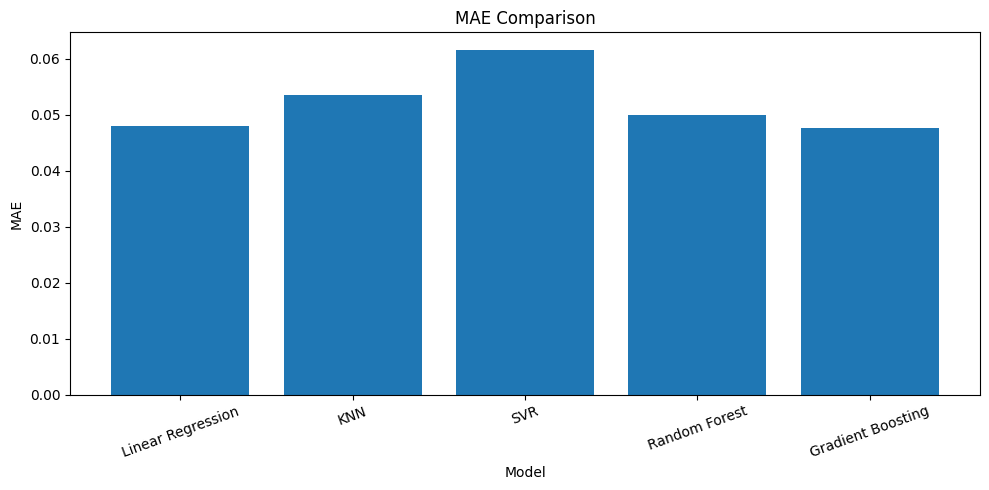

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    final_results["Model"],
    final_results["MAE"]
)

plt.xticks(rotation=20)

plt.xlabel("Model")
plt.ylabel("MAE")

plt.title("MAE Comparison")

plt.tight_layout()

plt.show()

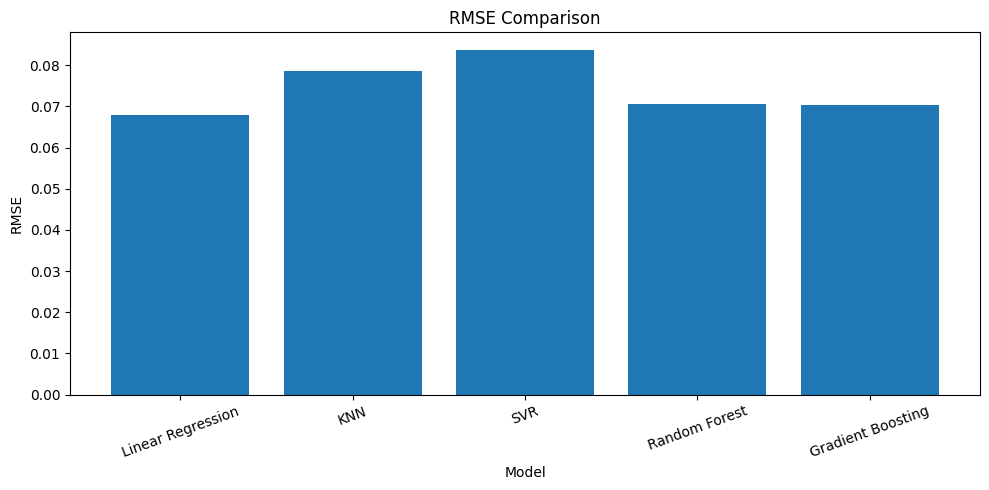

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    final_results["Model"],
    final_results["RMSE"]
)

plt.xticks(rotation=20)

plt.xlabel("Model")
plt.ylabel("RMSE")

plt.title("RMSE Comparison")

plt.tight_layout()

plt.show()

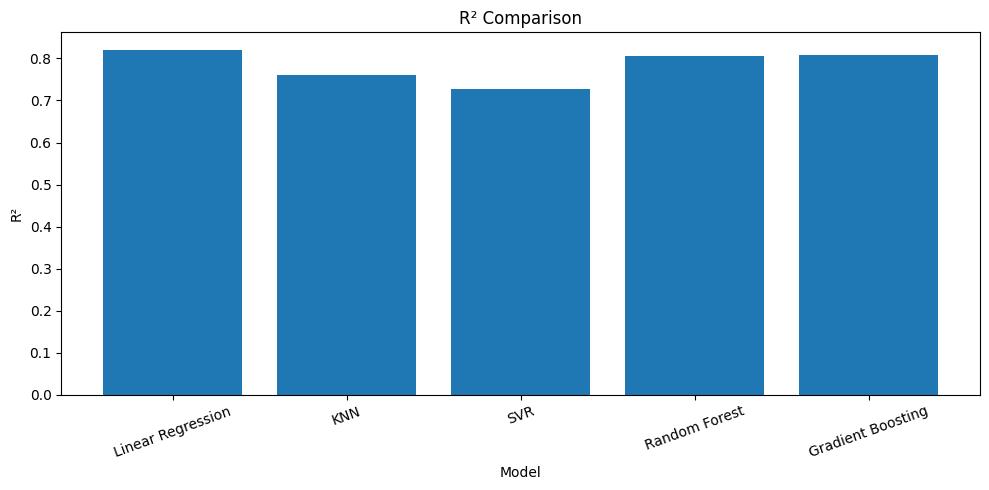

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    final_results["Model"],
    final_results["R2"]
)

plt.xticks(rotation=20)

plt.xlabel("Model")
plt.ylabel("R²")

plt.title("R² Comparison")

plt.tight_layout()

plt.show()

In [ ]:
selected_model = "Gradient Boosting"

y_pred = predictions[selected_model]

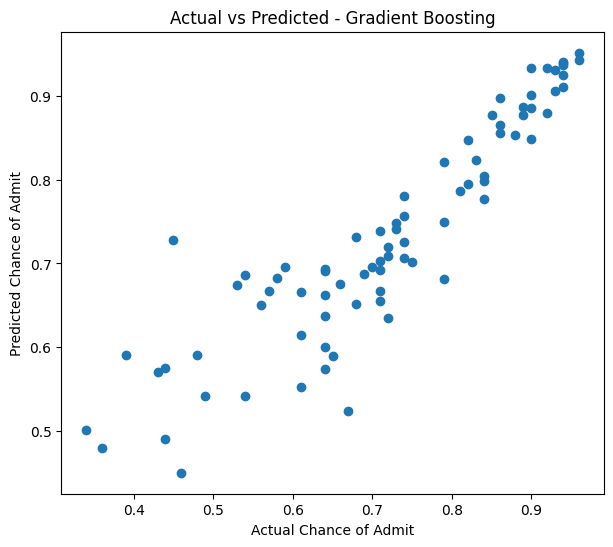

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Chance of Admit")
plt.ylabel("Predicted Chance of Admit")

plt.title(
    f"Actual vs Predicted - {selected_model}"
)

plt.show()

In [ ]:
residuals = y_test - y_pred

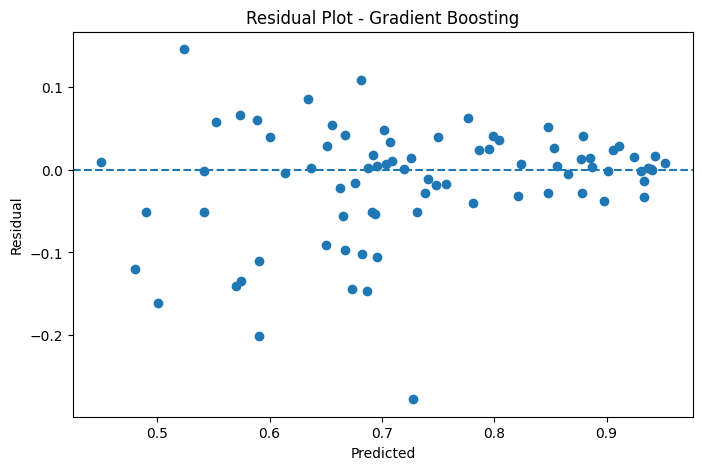

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted")
plt.ylabel("Residual")

plt.title(
    f"Residual Plot - {selected_model}"
)

plt.show()

In [ ]:
gb_final = models["Gradient Boosting"]

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_final.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
5,CGPA,0.601199
0,GRE Score,0.318075
3,SOP,0.030133
1,TOEFL Score,0.015940
4,LOR,0.012467
6,Research,0.011166
2,University Rating,0.011021


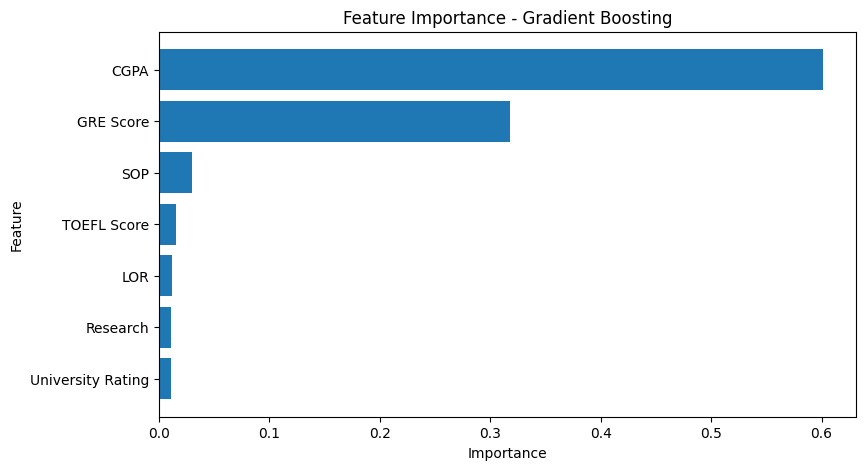

In [ ]:
plt.figure(figsize=(9, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Feature Importance - Gradient Boosting"
)

plt.gca().invert_yaxis()

plt.show()

In [ ]:
KNeighborsRegressor(
    n_neighbors=7,
    p=1,
    weights="distance"
)

KNeighborsRegressor(n_neighbors=7, p=1, weights='distance')